# PCA embedding + decoding of stimulus / choice over time (one session per region)
For the example session (most neurons) of each region: at each PSTH timepoint, embed the population with PCA **inside each CV fold (leak-free)** and decode from the first k components. Result = a (n_components x time) balanced-accuracy matrix per region. Stimulus-side decoding uses **contrast>0** trials; choice uses all. `WIN_BINS` = activity window swept across the PSTH.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [8]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'

REGION_LEVEL = 'beryl'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
WIN_BINS = 5               # activity window width (bins) swept across the PSTH
MAX_COMPONENTS = 15        # decode using 1..this many PCA components
CV_FOLDS = 5
MIN_NEURONS = 15
MIN_TRIALS = 40
SEED = 0

trials_df = pd.read_parquet(trials_path)
choice_by_session = {s: g.set_index('trial_id')['choice'] for s, g in trials_df.groupby('session')}
block_by_session = {s: g.set_index('trial_id')['block'] for s, g in trials_df.groupby('session')}
br = BrainRegions()
print("params set")

params set


## Pick one example session (most neurons) per region

In [3]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)

best = {}   # region -> dict(n, X[trials,neurons,T], stim, contrast, choice, session)
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values
        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        cond = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials)
        stim = cond.str.split('_').str[0].map({'Left': 0, 'Right': 1}).values.astype(float)
        contrast = cond.str.split('_').str[1].astype(float).values
        ch = choice_by_session.get(session, pd.Series(dtype=object)).reindex(trials)
        choice = ch.map({'left': 0, 'right': 1}).values.astype(float)
        blk = block_by_session.get(session, pd.Series(dtype=float)).reindex(trials)
        block = blk.map({0.2: 0.0, 0.8: 1.0}).values.astype(float)   # 0.5 -> NaN (excluded)
        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            if region not in best or len(ni) > best[region]['n']:
                best[region] = dict(n=len(ni), session=session,
                                    X=np.transpose(A[ni], (1, 0, 2)),   # trials x neurons x T
                                    stim=stim, contrast=contrast, choice=choice, block=block)
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

regions = sorted(best, key=lambda r: best[r]['n'], reverse=True)
print("Example session per region (n neurons):")
for r in regions: print(f"  {r:10s}: {best[r]['n']} neurons, session {best[r]['session'][:8]}")

  100/380 files...
  200/380 files...
  300/380 files...
Example session per region (n neurons):
  CUL4 5    : 217 neurons, session f10efe41
  MOp       : 214 neurons, session 8d316998
  ORBvl     : 160 neurons, session 1191f865
  LSr       : 159 neurons, session 4ecb5d24
  ENTm      : 135 neurons, session bda2faf5
  MOB       : 125 neurons, session 4ecb5d24
  VPM       : 117 neurons, session 4a45c8ba
  CP        : 113 neurons, session 88d24c31
  PO        : 111 neurons, session 746d1902
  UVU       : 111 neurons, session bb8d9451
  CENT3     : 108 neurons, session eef82e27
  MD        : 107 neurons, session ee40aece
  COPY      : 100 neurons, session 8c025071
  PIR       : 92 neurons, session 27ef44c0
  SSp-m     : 92 neurons, session e56541a5
  DG        : 90 neurons, session fcd49e34
  PYR       : 90 neurons, session 91796ceb
  ENTl      : 88 neurons, session 8ca740c5
  AIv       : 88 neurons, session 0f77ca5d
  SUB       : 85 neurons, session 35ed605c
  MG        : 85 neurons, sess

## Decode (leak-free PCA in-fold) vs #components x time

In [9]:
def decode_matrix(X, y, valid, K, cv, win, seed=SEED):
    """X: trials x neurons x T ; y: labels (nan allowed); valid: extra trial mask.
    Leak-free: StandardScaler + PCA fit on each train fold only. Returns (K x T) balanced accuracy."""
    Xw = uniform_filter1d(X, win, axis=2, mode='nearest')     # window over activity (time axis)
    Tn = X.shape[2]
    acc = np.full((K, Tn), np.nan)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    for t in range(Tn):
        Xt = Xw[:, :, t]
        m = valid & ~np.isnan(y) & ~np.isnan(Xt).any(axis=1)
        Xt2, yt = Xt[m], y[m].astype(int)
        if Xt2.shape[0] < MIN_TRIALS or len(np.unique(yt)) < 2 or min(np.bincount(yt)) < cv:
            continue
        per_k = np.full((K, cv), np.nan)
        for fi, (tr, te) in enumerate(skf.split(Xt2, yt)):
            sc = StandardScaler().fit(Xt2[tr])
            Xtr, Xte = sc.transform(Xt2[tr]), sc.transform(Xt2[te])
            nc = min(K, Xtr.shape[1], Xtr.shape[0] - 1)
            pca = PCA(n_components=nc, random_state=seed).fit(Xtr)
            Ztr, Zte = pca.transform(Xtr), pca.transform(Xte)
            for k in range(1, nc + 1):
                clf = LDA().fit(Ztr[:, :k], yt[tr])
                per_k[k - 1, fi] = balanced_accuracy_score(yt[te], clf.predict(Zte[:, :k]))
        acc[:, t] = np.nanmean(per_k, axis=1)
    return acc

decode_stim, decode_choice, decode_block = {}, {}, {}
for r in regions[7:8]:
    b = best[r]
    decode_stim[r] = decode_matrix(b['X'], b['stim'], b['contrast'] > 0, MAX_COMPONENTS, CV_FOLDS, WIN_BINS)
    # decode_choice[r] = decode_matrix(b['X'], b['choice'], np.ones(len(b['choice']), bool), MAX_COMPONENTS, CV_FOLDS, WIN_BINS)
    # decode_block[r] = decode_matrix(b['X'], b['block'], ~np.isnan(b['block']), MAX_COMPONENTS, CV_FOLDS, WIN_BINS)
print("decoding matrices computed for", len(regions), "regions")

decoding matrices computed for 169 regions


In [10]:
use_regions = regions[7:8]

## Heatmaps: decoding accuracy (components x time)

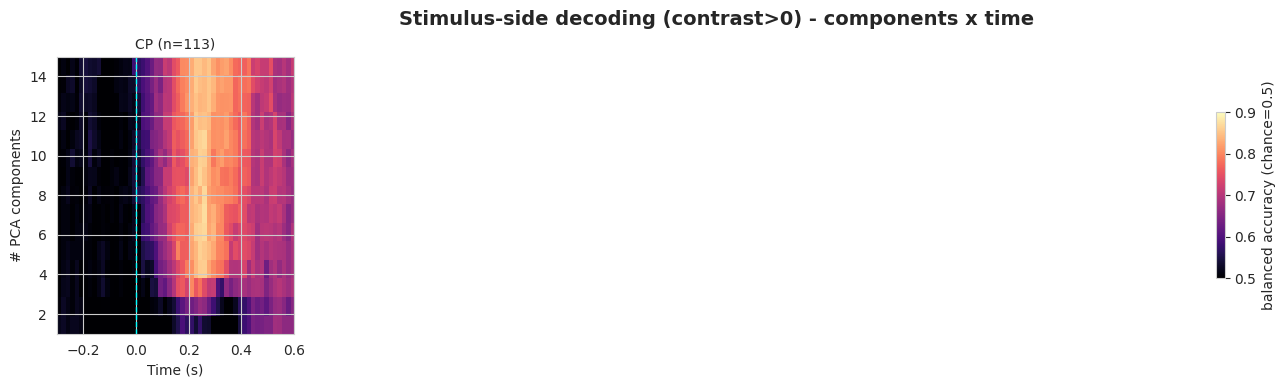

In [11]:
def plot_decode_grid(mats, title):
    regs = [r for r in use_regions if not np.all(np.isnan(mats[r]))]
    ncols = 4; nrows = int(np.ceil(len(regs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.6 * nrows), squeeze=False)
    for k, r in enumerate(regs):
        ax = axes[k // ncols][k % ncols]
        im = ax.imshow(mats[r], aspect='auto', origin='lower', cmap='magma', vmin=0.5, vmax=0.9,
                       extent=[tsec[0], tsec[-1], 1, mats[r].shape[0]])
        ax.axvline(0, color='cyan', ls='--', lw=1)
        ax.set_title(f'{r} (n={best[r]["n"]})', fontsize=10)
        ax.set_xlabel('Time (s)'); ax.set_ylabel('# PCA components'); ax.set_xlim([-0.3, 0.6])
    for k in range(len(regs), nrows * ncols):
        axes[k // ncols][k % ncols].axis('off')
    fig.colorbar(im, ax=axes, shrink=0.6, label='balanced accuracy (chance=0.5)')
    fig.suptitle(title, y=1.01, fontsize=14, fontweight='bold')
    plt.show()

plot_decode_grid(decode_stim, 'Stimulus-side decoding (contrast>0) - components x time')
# plot_decode_grid(decode_choice, 'Choice decoding - components x time')
# plot_decode_grid(decode_block, 'Block (0.2 vs 0.8, prior) decoding - components x time')